In [3]:
import math as maths

import cartopy.crs as ccrs
import intake
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

import easygems.healpix as egh

/home/users/mmuetz/miniforge3/envs/hackathon_env/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [4]:
import warnings

# Suppress specific FutureWarnings matching the message pattern when using cat[...].to_dask()
warnings.filterwarnings(
    "ignore",
    message=".*The return type of `Dataset.dims` will be changed.*",
    category=FutureWarning,
)

In [5]:
cat = intake.open_catalog('https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml')['online']

In [4]:
# Open a dataset.
ds = cat['um_glm_n2560_RAL3p3'](zoom=10, time='PT1H').to_dask()

In [5]:
ds.isel(time=5496).clivi.values

array([2.0719042e-05, 1.0000793e-05, 9.4107418e-06, ..., 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00], dtype=float32)

In [6]:
ds.isel(time=5497).clivi.values

array([nan, nan, nan, ..., nan, nan, nan], dtype=float32)

In [7]:
ds.isel(time=5497).clivi.values

array([1.4464472e-07, 1.3176083e-07, 1.5727905e-07, ..., 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00], dtype=float32)

In [10]:
cat['um_glm_n2560_RAL3p3'](zoom=9, time='PT1H').to_dask().isel(time=[5496, 5497]).clivi.values

array([[1.1172917e-05, 1.9287295e-06, 1.8704560e-06, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [1.3956289e-07, 1.7119694e-07, 1.8693460e-07, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00]], dtype=float32)

In [11]:
cat['um_glm_n2560_RAL3p3'](zoom=8, time='PT1H').to_dask().isel(time=[5496, 5497]).clivi.values

array([[3.8436206e-06, 2.9233044e-07, 5.2024325e-07, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [          nan,           nan,           nan, ...,           nan,
                  nan,           nan]], dtype=float32)

In [13]:
cat['um_glm_n2560_RAL3p3'](zoom=8, time='PT1H').to_dask().isel(time=[5496, 5497]).clivi.values

array([[3.8436206e-06, 2.9233044e-07, 5.2024325e-07, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [1.6972250e-07, 1.5247714e-07, 1.8341857e-06, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00]], dtype=float32)

<Figure size 640x480 with 0 Axes>

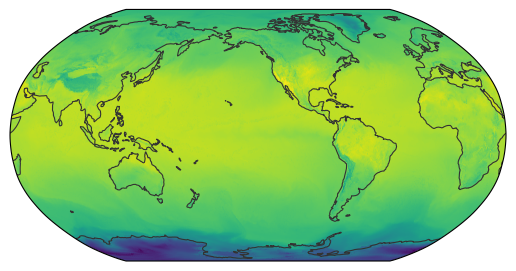

In [15]:
egh.healpix_show(cat['um_glm_n2560_RAL3p3'](zoom=8, time='PT1H').to_dask().isel(time=5497).tas.values)

In [6]:
cat['um_glm_n2560_RAL3p3'](zoom=8, time='PT1H').to_dask().isel(time=5497).time

<xarray.DataArray 'time' ()> Size: 8B
array('2020-09-05T01:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    crs      float64 8B ...
    time     datetime64[ns] 8B 2020-09-05T01:00:00